loss func 1.2360405507384784
loss func 0.8463527209903231
loss func 0.317280207687757
loss func 0.167253407367278
loss func 0.11411919069802923
loss func 0.10026379675636182
loss func 0.04418458869454389
loss func 0.04054137297814485
loss func 0.0320207942857134
loss func 0.028744723792863216
loss func 0.028784276246234555
loss func 0.028973455278281695
loss func 0.029318886249878048
loss func 0.028674900129002118
loss func 0.029311817026176083
loss func 0.02934916368546873
loss func 0.030507059213018748
loss func 0.028908034016177687
loss func 0.028723945158795894
loss func 0.028842574623676166
loss func 0.028943090235309384
loss func 0.0289213678670815
loss func 0.030287045419714283
loss func 0.030056073534711684
loss func 0.029731862021111534
loss func 0.03002943647290459
loss func 0.03005488965618375
loss func 0.030047497013501356
loss func 0.030052630206914323
loss func 0.029965731307888776
loss func 0.029988343625182778
loss func 0.029902495746265717
loss func 0.02994757665936933

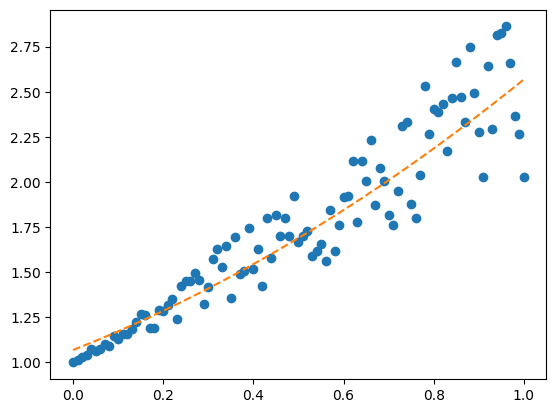

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Mon Dec  4 10:38:57 2023

@author: whadyimac
ejemplo gradient descent with least squares
https://towardsdatascience.com/learning-rate-schedules-and-adaptive-learning-rate-methods-for-deep-learning-2c8f433990d1
"""
import numpy as np
import matplotlib.pyplot as plt

ndata=101
xdata=np.linspace(0, 1, ndata)
ydata=1 + xdata + xdata * np.random.random(len(xdata))
nparam=3
np.random.seed(700)

def m(x,*p):
    y=p[0][0]*x**2+p[0][1]*x+p[0][2]
    return y

def E(p,*args):
    nrandom=args[0]
    iflag=args[1] #0 si no se calcula E2 y 1 si se calcula E2
    ep=np.zeros(ndata)
    E2=0
    E2random=0
    if iflag==1:
        for i in range(ndata):
            ep[i]=(ydata[i]-m(xdata[i],p))**2
            E2+=ep[i]
        E2=E2/ndata
    if iflag==0:
        ep[nrandom]=(ydata[nrandom]-m(xdata[nrandom],p))**2
        E2random=ep[nrandom]
    return E2,E2random,ep

def grad(p,*args):
    nrandom=args[0]
    n=len(p)
    y=np.zeros(n)
    dp=np.zeros(n)
    eps=1.0e-6
    for i in range(n):
        dp[i]=eps
#        y[i]=(E(p+dp,args)[0]-E(p,args)[0])/eps #whole gradient
        y[i]=(E(p+dp,nrandom,0)[1]-E(p,nrandom,0)[1])/eps #stochastic subgradient
        dp[i]=0.0
    return y

lr=0.1

p0=np.random.random(nparam)
itermax=200

for i in range(itermax):
    nrand=np.random.randint(ndata)
    p=p0-lr*grad(p0,nrand)
    p0[:]=p
    kr=0.01
    lr*=1.0/(1.0+kr*i)
    print('loss func',E(p,nrand,1)[0])

ypred=np.zeros(ndata)
for i in range(ndata):
    ypred[i]=m(xdata[i],p)


fig, ax = plt.subplots()
ax.plot(xdata, ydata, 'o')
ax.plot(xdata, ypred, '--')









